# Area Classifier

**Nessun prerequisito Colab in questa fase** — gli embedding sono già stati calcolati su GPU (Colab) e salvati come file `.npy`.

### Pipeline
1. Carica i 4 file `.npy` dalla cartella `embeddings/`
2. Verifica allineamento e normalizzazione L2
3. Tuning C con 3-fold CV
4. Training LinearSVC + valutazione
5. Salvataggio in `modelli/area_v2/`

### File richiesti in `embeddings/`
```
area_v2_e5_train.npy       ← embedding train  (n_train × 768)
area_v2_e5_test.npy        ← embedding test   (n_test  × 768)
area_v2_labels_train.npy   ← label train      (array di stringhe)
area_v2_labels_test.npy    ← label test       (array di stringhe)

---
## STEP 1 — Import e configurazione percorsi

In [1]:
import pandas as pd
import numpy as np
import warnings
import time
import os
from pathlib import Path
warnings.filterwarnings('ignore')

BASE_DIR = Path(os.path.abspath('')).parent

DATA_DIR = BASE_DIR / 'data'
EMB_DIR  = BASE_DIR / 'embeddings'
MOD_DIR  = BASE_DIR / 'modelli'

CSV_PATH          = DATA_DIR / 'dataset_clean.csv'
EMB_TRAIN_PATH    = EMB_DIR / 'e5_train.npy'
EMB_TEST_PATH     = EMB_DIR / 'e5_test.npy'
LABELS_TRAIN_PATH = EMB_DIR / 'e5_train.npy'  # non più usato, ma tienilo per il check exists
LABELS_TEST_PATH  = EMB_DIR / 'e5_test.npy'   # stesso

SOGLIA_SPLIT = '2025-11-01'

print(f'BASE_DIR : {BASE_DIR}')
print()
for p in [CSV_PATH, EMB_TRAIN_PATH, EMB_TEST_PATH, LABELS_TRAIN_PATH, LABELS_TEST_PATH]:
    stato = 'OK' if p.exists() else 'MANCANTE ⚠️'
    print(f'  {p.name:<40} {stato}')

BASE_DIR : c:\Users\matteo.segatto\Desktop\TicketClassifier

  dataset_clean.csv                        OK
  e5_train.npy                             OK
  e5_test.npy                              OK
  e5_train.npy                             OK
  e5_test.npy                              OK


---
## STEP 2 — Pulizia classi area (v2)

Riproduciamo qui la logica di preprocessing che viveva su Colab, per documentazione e riproducibilità.
Rinomina: Hardware → area_sistemistica
Drop: business_intelligence e protocollo_delibere
Drop classi con < 10 ticket totali 
> **Nota**: questa cella è solo documentazione — `y_train` e `y_test` vengono caricati dai file `.npy` nel passo successivo, garantendo allineamento perfetto con gli embedding.

In [2]:
# Carico il CSV per applicare la pulizia e mostrare la distribuzione finale
df = pd.read_csv(CSV_PATH, parse_dates=['data_creazione'])

# 1. Rinomino Hardware → area_sistemistica
df['area_v2'] = df['area'].replace({'Hardware': 'area_sistemistica'})

# 2. Droppo classi irrecuperabili
CLASSI_DROP = ['business_intelligence', 'protocollo_delibere']
df.loc[df['area_v2'].isin(CLASSI_DROP), 'area_v2'] = np.nan

# 3. Droppo classi con meno di 10 ticket (rumore statistico)
conteggi = df['area_v2'].value_counts()
classi_rumore = conteggi[conteggi < 10].index.tolist()
if classi_rumore:
    print(f'Classi droppate per rumore (< 10 ticket): {classi_rumore}')
    df.loc[df['area_v2'].isin(classi_rumore), 'area_v2'] = np.nan

# 4. Split temporale (stesso usato in Colab per generare gli .npy)
df_validi   = df.dropna(subset=['area_v2'])
df_train_doc = df_validi[df_validi['data_creazione'] < SOGLIA_SPLIT]
df_test_doc  = df_validi[df_validi['data_creazione'] >= SOGLIA_SPLIT]

print('=== Distribuzione area_v2 — dataset completo ===')
print(df['area_v2'].value_counts(dropna=False).to_string())
print()
print(f'Ticket usabili (area_v2 valorizzata): {len(df_validi):,}')
print(f'  → Train (< {SOGLIA_SPLIT}): {len(df_train_doc):,}')
print(f'  → Test  (≥ {SOGLIA_SPLIT}): {len(df_test_doc):,}')
print()
print('(y_train e y_test vengono dai file .npy — questo blocco è solo documentazione)')

Classi droppate per rumore (< 10 ticket): ['Amministrazione', 'Personale', 'CSS', 'Utenti e Ospiti', 'flussi_regionali']
=== Distribuzione area_v2 — dataset completo ===
area_v2
area_personale                     14240
ciclo_passivo                      10985
ciclo_attivo                        9228
area_sanitaria                      8742
NaN                                 6234
rendicontazione_flussi              2852
protocollo_documentale_delibere     2578
area_sistemistica                   1950
sistema381                          1000
area_territoriale                    535

Ticket usabili (area_v2 valorizzata): 52,110
  → Train (< 2025-11-01): 41,789
  → Test  (≥ 2025-11-01): 10,321

(y_train e y_test vengono dai file .npy — questo blocco è solo documentazione)


---
## STEP 3 — Caricamento embedding e label

Carico direttamente i 4 file `.npy` prodotti dal Colab.
Label e embedding sono garantiti allineati perché generati insieme.

In [3]:
for p in [EMB_TRAIN_PATH, EMB_TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f'File non trovato: {p}\n'
            f'Scarica i file .npy da Kaggle e mettili in: {EMB_DIR}'
        )

# Carica tutti gli embedding (tutti i ticket, nessun filtro)
X_train_full = np.load(EMB_TRAIN_PATH)
X_test_full  = np.load(EMB_TEST_PATH)

# Gli embedding coprono tutti i ticket del split temporale.
# df_train_doc e df_test_doc sono sottoinsiemi filtrati (solo ticket con area).
# Ricaviamo gli indici posizionali di df_train_doc dentro il split completo.
df_all_train = df[df['data_creazione'] <  SOGLIA_SPLIT]
df_all_test  = df[df['data_creazione'] >= SOGLIA_SPLIT]

idx_train = df_all_train.index.get_indexer(df_train_doc.index)
idx_test  = df_all_test.index.get_indexer(df_test_doc.index)

X_train = X_train_full[idx_train]
X_test  = X_test_full[idx_test]

y_train = df_train_doc['area_v2'].values
y_test  = df_test_doc['area_v2'].values

print(f'X_train : {X_train.shape}  — atteso ({len(df_train_doc)}, 768)')
print(f'X_test  : {X_test.shape}   — atteso ({len(df_test_doc)}, 768)')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

assert X_train.shape[0] == len(y_train), f'MISMATCH TRAIN: {X_train.shape[0]} vs {len(y_train)}'
assert X_test.shape[0]  == len(y_test),  f'MISMATCH TEST:  {X_test.shape[0]} vs {len(y_test)}'
print('Allineamento OK ✓')

X_train : (41789, 768)  — atteso (41789, 768)
X_test  : (10321, 768)   — atteso (10321, 768)
y_train : (41789,)
y_test  : (10321,)
Allineamento OK ✓


---
## STEP 3b — OHE `priorita_iniziale_cliente` + costruzione feature matrix finale

Concatena alla matrice degli embedding una feature one-hot per `priorita_iniziale_cliente`.  
NaN → vettore di zeri (gestito automaticamente da `handle_unknown='ignore'`).

In [4]:
import scipy.sparse as sp
from sklearn.preprocessing import OneHotEncoder

# ── OHE priorita_iniziale_cliente ─────────────────────────────────────────────
CAT_COLS = ['priorita_iniziale_cliente']

encoder_cat = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoder_cat.fit(df_train_doc[CAT_COLS])

X_cat_train = encoder_cat.transform(df_train_doc[CAT_COLS])
X_cat_test  = encoder_cat.transform(df_test_doc[CAT_COLS])

print(f'Feature OHE priorità: {X_cat_train.shape[1]} colonne')
print(f'  Categorie: {encoder_cat.categories_[0].tolist()}')

# ── Keyword booleane ──────────────────────────────────────────────────────────
# Colonne binarie aggiunte al CSV dal preprocessing (STEP 9b).
# Coprono le 4 classi con F1 più basso: sistema381, area_territoriale,
# ciclo_passivo, ciclo_attivo.
KW_COLS = [c for c in df_train_doc.columns if c.startswith('kw_')]
print(f'\nFeature keyword: {len(KW_COLS)} colonne')
print(f'  {KW_COLS}')

# Convertiamo le colonne bool in matrice sparsa (0/1)
X_kw_train = sp.csr_matrix(df_train_doc[KW_COLS].astype(float).values)
X_kw_test  = sp.csr_matrix(df_test_doc[KW_COLS].astype(float).values)

# ── Costruzione feature matrix finale ─────────────────────────────────────────
# [embedding 768d | OHE priorità 4d | keyword booleane 18d]
X_train = sp.hstack([sp.csr_matrix(X_train), X_cat_train, X_kw_train])
X_test  = sp.hstack([sp.csr_matrix(X_test),  X_cat_test,  X_kw_test])

print(f'\nFeature matrix train: {X_train.shape}')
print(f'Feature matrix test:  {X_test.shape}')
print(f'  embedding: 768  |  OHE: {X_cat_train.shape[1]}  |  keyword: {len(KW_COLS)}  |  totale: {X_train.shape[1]}')

Feature OHE priorità: 4 colonne
  Categorie: ['P1', 'P2', 'P3', 'P4']

Feature keyword: 25 colonne
  ['kw_s381_codice', 'kw_s381_rapportino', 'kw_s381_timbrate', 'kw_s381_calendario_presenze', 'kw_ter_unodomo', 'kw_ter_distretto', 'kw_san_terapia', 'kw_san_pai', 'kw_san_css', 'kw_san_diario', 'kw_san_contenzioni', 'kw_san_farmaco', 'kw_pas_iva', 'kw_pas_cespiti', 'kw_pas_prima_nota', 'kw_pas_ammortamento', 'kw_pas_analitica', 'kw_pas_reverse', 'kw_pas_fornitore', 'kw_att_retta', 'kw_att_pagopa', 'kw_att_sdd', 'kw_att_portale_utenti', 'kw_att_fattura_elettronica', 'kw_sis_installazione_programma']

Feature matrix train: (41789, 797)
Feature matrix test:  (10321, 797)
  embedding: 768  |  OHE: 4  |  keyword: 25  |  totale: 797


---
## STEP 4 — Verifica allineamento e distribuzione classi

In [5]:
# X_train/X_test sono ora sparse matrix → usare .shape[0] invece di len()
assert X_train.shape[0] == len(y_train), f'MISMATCH TRAIN: {X_train.shape[0]} emb vs {len(y_train)} label'
assert X_test.shape[0]  == len(y_test),  f'MISMATCH TEST:  {X_test.shape[0]} emb vs {len(y_test)} label'
print('Allineamento OK')
print()

# Verifica normalizzazione L2 sui primi 768d (embedding) — gli altri sono 0/1
# .toarray() necessario per passare da sparse a numpy
norme = np.linalg.norm(X_train[:5, :768].toarray(), axis=1)
print(f'Norma L2 primi 5 vettori train (atteso ~1.0): {norme.round(4)}')
print()

print('Classi nel train:')
print(pd.Series(y_train).value_counts().to_string())
print()
print('Classi nel test:')
print(pd.Series(y_test).value_counts().to_string())

Allineamento OK

Norma L2 primi 5 vettori train (atteso ~1.0): [1. 1. 1. 1. 1.]

Classi nel train:
area_personale                     11076
ciclo_passivo                       8921
ciclo_attivo                        7354
area_sanitaria                      7318
rendicontazione_flussi              2457
protocollo_documentale_delibere     1894
area_sistemistica                   1499
sistema381                           828
area_territoriale                    442

Classi nel test:
area_personale                     3164
ciclo_passivo                      2064
ciclo_attivo                       1874
area_sanitaria                     1424
protocollo_documentale_delibere     684
area_sistemistica                   451
rendicontazione_flussi              395
sistema381                          172
area_territoriale                    93


---
## STEP 5 — Tuning parametro C con cross-validation

`C` controlla il tradeoff bias/varianza in LinearSVC:
- **C piccolo** → forte regolarizzazione, margine largo, rischio underfitting
- **C grande** → poca regolarizzazione, rischio overfitting

Con embedding L2-normalizzati i valori ottimali tipici stanno tra 0.5 e 10.  
Usiamo 3-fold CV per velocità — su ~40k ticket è già robusto.

In [6]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

VALORI_C = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# StratifiedKFold mantiene la proporzione delle classi in ogni fold,
# importante per classi piccole come area_territoriale
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print('Tuning parametro C — LinearSVC (3-fold CV, metrica: macro F1)')
print(f'{"C":>6}  {"F1 macro":>10}  {"Std":>8}  {"Tempo":>8}')
print('-' * 42)

risultati_c = {}
for c in VALORI_C:
    clf_tmp = LinearSVC(class_weight='balanced', max_iter=3000, C=c, random_state=42)
    t0 = time.time()
    scores = cross_val_score(
        clf_tmp, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    elapsed = time.time() - t0
    risultati_c[c] = scores.mean()
    print(f'{c:>6.1f}  {scores.mean():>10.4f}  {scores.std():>8.4f}  {elapsed:>7.0f}s')

C_OTTIMALE = max(risultati_c, key=risultati_c.get)
print(f'\nC ottimale selezionato: {C_OTTIMALE}  (F1 macro = {risultati_c[C_OTTIMALE]:.4f})')

Tuning parametro C — LinearSVC (3-fold CV, metrica: macro F1)
     C    F1 macro       Std     Tempo
------------------------------------------
   0.1      0.6607    0.0076       72s
   0.5      0.6761    0.0047       76s
   1.0      0.6816    0.0023       84s
   2.0      0.6822    0.0022       91s
   5.0      0.6830    0.0033      102s
  10.0      0.6835    0.0035      108s

C ottimale selezionato: 10.0  (F1 macro = 0.6835)


---
## STEP 6 — Training e valutazione finale

In [7]:
from sklearn.metrics import classification_report, f1_score

print(f'Training LinearSVC con C={C_OTTIMALE}...')
t0 = time.time()

clf_final = LinearSVC(
    class_weight='balanced',
    C=C_OTTIMALE,
    max_iter=3000,
    random_state=42
)
clf_final.fit(X_train, y_train)
print(f'Training completato in {time.time() - t0:.1f}s')
print()

y_pred = clf_final.predict(X_test)
macro_f1 = f1_score(y_test, y_pred, average='macro')
accuracy  = (y_pred == y_test).mean()

print(f'{"="*60}')
print(f'RISULTATI AREA CLASSIFIER v2 (E5-base + LinearSVC)')
print(f'{"="*60}')
print(f'Macro F1:  {macro_f1:.4f}')
print(f'Accuracy:  {accuracy:.4f}')
print()
print(classification_report(y_test, y_pred, zero_division=0))

Training LinearSVC con C=10.0...
Training completato in 129.3s

RISULTATI AREA CLASSIFIER v2 (E5-base + LinearSVC)
Macro F1:  0.6777
Accuracy:  0.7655

                                 precision    recall  f1-score   support

                 area_personale       0.91      0.86      0.88      3164
                 area_sanitaria       0.77      0.79      0.78      1424
              area_sistemistica       0.46      0.60      0.52       451
              area_territoriale       0.34      0.62      0.44        93
                   ciclo_attivo       0.74      0.68      0.71      1874
                  ciclo_passivo       0.78      0.70      0.74      2064
protocollo_documentale_delibere       0.76      0.85      0.80       684
         rendicontazione_flussi       0.63      0.82      0.71       395
                     sistema381       0.43      0.65      0.51       172

                       accuracy                           0.77     10321
                      macro avg       0.65 

---
## STEP 7 — Confusion matrix e analisi errori

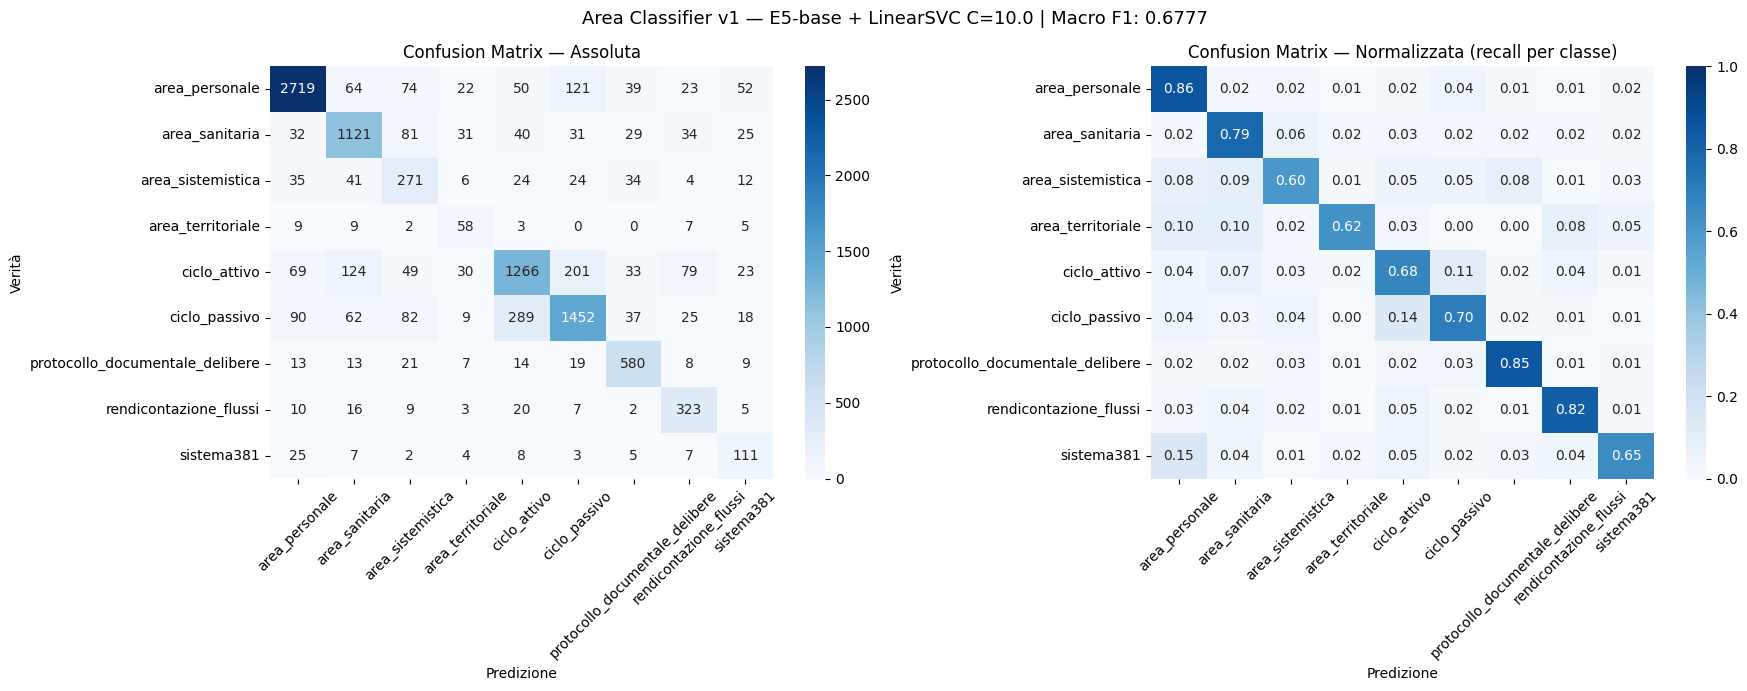

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

classi_ordinate = sorted(clf_final.classes_)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Confusion matrix assoluta ---
cm_abs = confusion_matrix(y_test, y_pred, labels=classi_ordinate)
sns.heatmap(
    cm_abs, annot=True, fmt='d', cmap='Blues',
    xticklabels=classi_ordinate, yticklabels=classi_ordinate,
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Assoluta')
axes[0].set_xlabel('Predizione')
axes[0].set_ylabel('Verità')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# --- Confusion matrix normalizzata (recall per classe) ---
cm_norm = confusion_matrix(y_test, y_pred, labels=classi_ordinate, normalize='true')
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=classi_ordinate, yticklabels=classi_ordinate,
    ax=axes[1], vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix — Normalizzata (recall per classe)')
axes[1].set_xlabel('Predizione')
axes[1].set_ylabel('Verità')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(f'Area Classifier v1 — E5-base + LinearSVC C={C_OTTIMALE} | Macro F1: {macro_f1:.4f}', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# ---------------------------------------------------------------------------
# TOP COPPIE DI CONFUSIONE
# Mostra quali classi vengono confuse tra loro
# ---------------------------------------------------------------------------
df_err = pd.DataFrame({'reale': y_test, 'predetto': y_pred})
errori = df_err[df_err['reale'] != df_err['predetto']]

print(f'Errori totali: {len(errori):,} su {len(y_test):,} ({len(errori)/len(y_test)*100:.1f}%)')
print()
print('Top 15 coppie di confusione (reale → predetto):')
print(
    errori.groupby(['reale', 'predetto'])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_string()
)

Errori totali: 2,420 su 10,321 (23.4%)

Top 15 coppie di confusione (reale → predetto):
reale           predetto              
ciclo_passivo   ciclo_attivo              289
ciclo_attivo    ciclo_passivo             201
                area_sanitaria            124
area_personale  ciclo_passivo             121
ciclo_passivo   area_personale             90
                area_sistemistica          82
area_sanitaria  area_sistemistica          81
ciclo_attivo    rendicontazione_flussi     79
area_personale  area_sistemistica          74
ciclo_attivo    area_personale             69
area_personale  area_sanitaria             64
ciclo_passivo   area_sanitaria             62
area_personale  sistema381                 52
                ciclo_attivo               50
ciclo_attivo    area_sistemistica          49


---
## STEP 8 — Analisi errori approfondita

Ricostruiamo il DataFrame di test con il testo originale per capire **dove** e **perché** sbaglia il modello.

In [10]:
import re

# df_test_doc è già stato costruito in STEP 2 — usiamo quello direttamente
df_test_err = df_test_doc.reset_index(drop=True).copy()

print(f'Righe test dal CSV : {len(df_test_err):,}')
print(f'y_test (.npy)      : {len(y_test):,}')
print()
print('Colonne disponibili:', df_test_err.columns.tolist())

# Verifica allineamento righe CSV e .npy
if len(df_test_err) != len(y_test):
    print('\n⚠️  MISMATCH — righe test CSV e .npy non coincidono.')
    print('   Soluzione: salva gli indici dal Colab e ricaricali qui.')
else:
    df_test_err['label_reale']    = y_test
    df_test_err['label_predetta'] = y_pred
    df_test_err['corretto']       = df_test_err['label_reale'] == df_test_err['label_predetta']

    n_err = (~df_test_err['corretto']).sum()
    print(f'\nAllineamento OK ✓')
    print(f'Errori: {n_err:,} / {len(df_test_err):,} ({n_err/len(df_test_err)*100:.1f}%)')

Righe test dal CSV : 10,321
y_test (.npy)      : 10,321

Colonne disponibili: ['url_ticket', 'case_number', 'testo_input', 'priorita_finale', 'priorita_iniziale_cliente', 'area', 'articolo', 'modulo_sw', 'has_urgenza', 'n_parole', 'data_creazione', 'kw_s381_codice', 'kw_s381_rapportino', 'kw_s381_timbrate', 'kw_s381_calendario_presenze', 'kw_ter_unodomo', 'kw_ter_distretto', 'kw_san_terapia', 'kw_san_pai', 'kw_san_css', 'kw_san_diario', 'kw_san_contenzioni', 'kw_san_farmaco', 'kw_pas_iva', 'kw_pas_cespiti', 'kw_pas_prima_nota', 'kw_pas_ammortamento', 'kw_pas_analitica', 'kw_pas_reverse', 'kw_pas_fornitore', 'kw_att_retta', 'kw_att_pagopa', 'kw_att_sdd', 'kw_att_portale_utenti', 'kw_att_fattura_elettronica', 'kw_sis_installazione_programma', 'area_v2']

Allineamento OK ✓
Errori: 2,420 / 10,321 (23.4%)


In [11]:
# ── Analisi lessicale: parole che il modello confonde ───────────────────────
# Per ogni coppia (reale → predetto), trova le parole più frequenti nei ticket
# sbagliati VS nei ticket correttamente classificati della stessa classe.

from collections import Counter

COPPIE_ANALISI = [
    ('ciclo_passivo',  'ciclo_attivo'),
    ('ciclo_attivo',   'ciclo_passivo'),
    ('area_personale', 'sistema381'),
    ('area_sanitaria', 'area_sistemistica'),
]

STOPWORDS = {
    'il', 'lo', 'la', 'i', 'gli', 'le', 'un', 'una', 'di', 'del', 'della',
    'dei', 'degli', 'delle', 'da', 'dal', 'dalla', 'a', 'al', 'alla', 'in',
    'nel', 'nella', 'nei', 'su', 'sul', 'sulla', 'con', 'per', 'tra', 'fra',
    'che', 'non', 'si', 'è', 'e', 'ma', 'o', 'se', 'come', 'anche', 'più',
    'questo', 'questa', 'questi', 'queste', 'ho', 'ha', 'sono', 'essere',
    'ci', 'mi', 'ti', 'vi', 'ne', 'salve', 'buongiorno', 'buonasera',
    'grazie', 'cordiali', 'saluti',
}

# Funzione di tokenizzazione semplice: minuscolo, rimuove punteggiatura, filtra stopwords e parole corte
def tokenizza(testo):
    testo = str(testo).lower()
    testo = re.sub(r'[^a-zàáèéìíòóùú\s]', ' ', testo)
    return [w for w in testo.split() if len(w) > 3 and w not in STOPWORDS]

# Analisi per ogni coppia di confusione
for reale, predetto in COPPIE_ANALISI:
    mask_errore   = (df_test_err['label_reale'] == reale) & (df_test_err['label_predetta'] == predetto)
    mask_corretto = (df_test_err['label_reale'] == reale) & (df_test_err['corretto'])

    testi_err = df_test_err.loc[mask_errore,   'testo_input']
    testi_ok  = df_test_err.loc[mask_corretto, 'testo_input']

    if len(testi_err) == 0:
        continue

    cnt_err = Counter(w for t in testi_err for w in tokenizza(t))
    cnt_ok  = Counter(w for t in testi_ok  for w in tokenizza(t))
    n_err_pair = len(testi_err)
    n_ok_pair  = len(testi_ok)

    parole_sospette = []
    for parola, freq_e in cnt_err.items():
        freq_o  = cnt_ok.get(parola, 0)
        ratio_e = freq_e / n_err_pair
        ratio_o = freq_o / max(n_ok_pair, 1)
        if ratio_e >= 0.05 and ratio_e > ratio_o * 1.5:
            parole_sospette.append((parola, freq_e, round(ratio_e, 3), round(ratio_o, 3)))

    parole_sospette.sort(key=lambda x: -x[2])

    print(f'{"─"*60}')
    print(f'REALE: {reale}  →  PREDETTO: {predetto}  ({n_err_pair} errori)')
    print(f'{"Parola":<20} {"Freq err":>9} {"Ratio err":>10} {"Ratio ok":>9}')
    for p, f, re_, ro in parole_sospette[:15]:
        print(f'{p:<20} {f:>9} {re_:>10.3f} {ro:>9.3f}')
    print()

────────────────────────────────────────────────────────────
REALE: ciclo_passivo  →  PREDETTO: ciclo_attivo  (289 errori)
Parola                Freq err  Ratio err  Ratio ok
fatture                    212      0.734     0.377
fatturazione               105      0.363     0.039
elettronica                103      0.356     0.048
elettroniche                52      0.180     0.051
invio                       49      0.170     0.072
codice                      48      0.166     0.085
sistema                     43      0.149     0.060
aggiornamento               38      0.131     0.055
nell                        37      0.128     0.083
credenziali                 32      0.111     0.012
modifica                    31      0.107     0.030
servizio                    31      0.107     0.018
canale                      30      0.104     0.006
sanitaria                   29      0.100     0.019
portale                     24      0.083     0.028

────────────────────────────────────────────

---
## STEP 8 — Salvataggio modello

In [12]:
import joblib
import json

SAVE_DIR = MOD_DIR / 'area_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(clf_final,   SAVE_DIR / 'classificatore_svc.pkl')
joblib.dump(encoder_cat, SAVE_DIR / 'encoder_cat.pkl')

metadata = {
    'versione': 'v2',
    'modello_embedding': 'intfloat/multilingual-e5-base',
    'prefisso_e5': 'query: ',
    'classificatore': 'LinearSVC',
    'C_ottimale': C_OTTIMALE,
    'class_weight': 'balanced',
    'feature': [
        'embedding_e5_768d',
        'ohe_priorita_iniziale_cliente',
        'keyword_booleane',
    ],
    'keyword_cols': KW_COLS,
    'classi': clf_final.classes_.tolist(),
    'split': 'temporale',
    'soglia_split': SOGLIA_SPLIT,
    'macro_f1_test': round(float(macro_f1), 4),
    'accuracy_test': round(float(accuracy), 4),
    'n_train': int(len(y_train)),
    'n_test': int(len(y_test)),
    'note': 'Hardware accorpato in area_sistemistica; business_intelligence e protocollo_delibere droppati'
}

with open(SAVE_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'Modello salvato in: {SAVE_DIR}')
print()
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Modello salvato in: c:\Users\matteo.segatto\Desktop\TicketClassifier\modelli\area_v2

{
  "versione": "v2",
  "modello_embedding": "intfloat/multilingual-e5-base",
  "prefisso_e5": "query: ",
  "classificatore": "LinearSVC",
  "C_ottimale": 10.0,
  "class_weight": "balanced",
  "feature": [
    "embedding_e5_768d",
    "ohe_priorita_iniziale_cliente",
    "keyword_booleane"
  ],
  "keyword_cols": [
    "kw_s381_codice",
    "kw_s381_rapportino",
    "kw_s381_timbrate",
    "kw_s381_calendario_presenze",
    "kw_ter_unodomo",
    "kw_ter_distretto",
    "kw_san_terapia",
    "kw_san_pai",
    "kw_san_css",
    "kw_san_diario",
    "kw_san_contenzioni",
    "kw_san_farmaco",
    "kw_pas_iva",
    "kw_pas_cespiti",
    "kw_pas_prima_nota",
    "kw_pas_ammortamento",
    "kw_pas_analitica",
    "kw_pas_reverse",
    "kw_pas_fornitore",
    "kw_att_retta",
    "kw_att_pagopa",
    "kw_att_sdd",
    "kw_att_portale_utenti",
    "kw_att_fattura_elettronica",
    "kw_sis_installazione_programm